In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import calendar

## Get the Data

The rainfall data comes from the [Met Office Hadley Centre dataset](https://www.metoffice.gov.uk/hadobs/hadukp/data/download.html). There is a general dataset for all of Scotland and 3 additional datasets for regions of Scotland.

First the data is imported into a Pandas DataFrame, then filtered for data up until 2025 as the 2026 year is not complete data. 

Next the data is filtered only for extremes. This was done by selecting the maximum rainfall in each month. Then the average from each month was found, giving the average monthly rainfall maxima.

In [3]:
df_scot = pd.read_csv('https://www.metoffice.gov.uk/hadobs/hadukp/data/daily/HadSP_daily_totals.txt',
            header = 2,
            sep=r'\s+',
            index_col = 'Date')


# Replace all -99 with nan
df_scot = df_scot.replace(-99.9, np.nan).dropna() 

# Set the index to the date then filter to only include data up to 2024
df_scot.index = pd.to_datetime(df_scot.index)
df_scot = df_scot.loc[:'2025']

df_scot.tail()

,Value
Date,
2025-12-27,0.23
2025-12-28,0.15
2025-12-29,0.30
2025-12-30,0.34
2025-12-31,5.54


In [4]:
# Sample the dataframe by month and select the maximum value for each month
m_max_scot = df_scot.resample('ME').max()

# Group the monthly maximums by month and calculate the mean for each month
max_months_grp_scot = m_max_scot.groupby(m_max_scot.index.month)
mean_months_scot = max_months_grp_scot.mean()

# Create a list of months then add to the dataframe
month_names = [i[:3] for i in list(calendar.month_name)[1:]]
mean_months_scot['Month'] = month_names

mean_months_scot.head()

,Value,Month
Date,,
1,17.638632,Jan
2,14.983053,Feb
3,14.731263,Mar
4,12.704842,Apr
5,13.216211,May


## Plotting

To start, the data can be plotted as a line graph. A horizontal line for the mean can be added to show whether a month falls above or below the average.

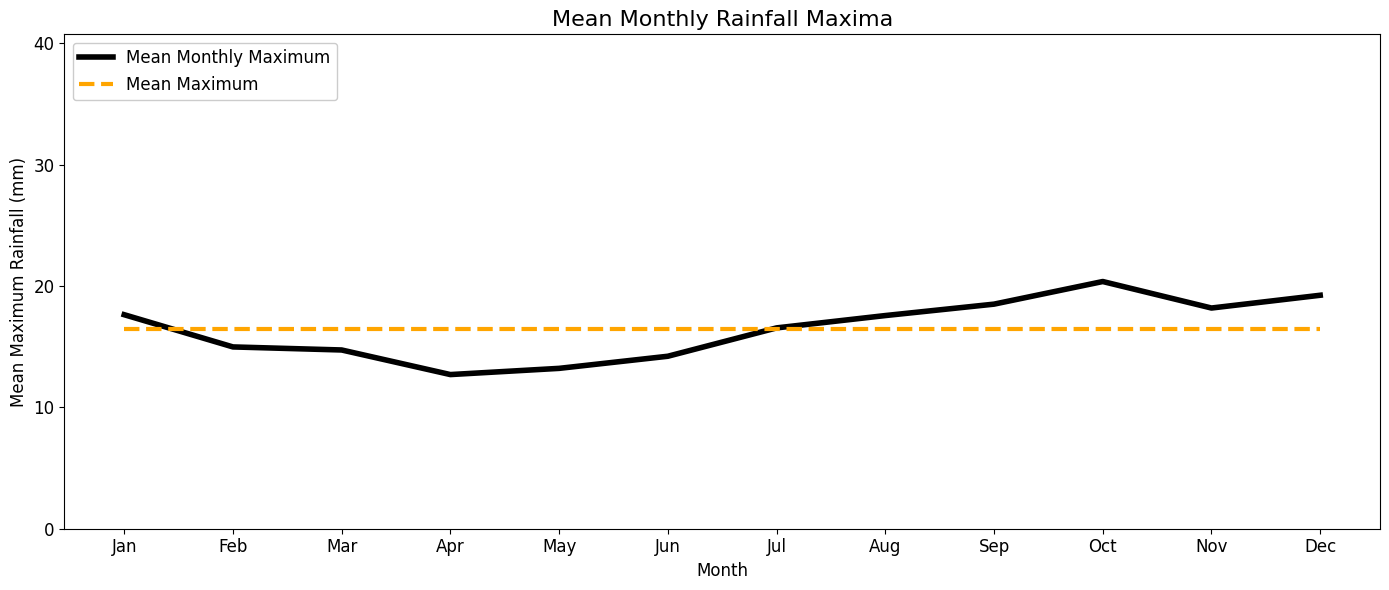

In [5]:
# Find the mean of all months
m_max_mean = m_max_scot['Value'].mean()

# Create the plotting object then plot the values of each month and the mean line
fig, axes = plt.subplots(figsize = (14, 6))

axes.plot(month_names, mean_months_scot['Value'], linewidth = 4, color = 'black', label = 'Mean Monthly Maximum')
axes.hlines(m_max_mean, 0, 11, 'orange', '--', linewidth = 3, label = 'Mean Maximum')

# Label and clean up the axes
axes.set_xticks(np.arange(0, 12))
axes.set_xticklabels(month_names, fontsize = 12)

axes.set_yticks(np.arange(0, 60, 10))
axes.set_yticklabels(np.arange(0, 60, 10), fontsize = 12)

axes.set_ylim(0, mean_months_scot['Value'].max()*2)

axes.set_title('Mean Monthly Rainfall Maxima', fontsize = 16)
axes.set_ylabel('Mean Maximum Rainfall (mm)', fontsize = 12)
axes.set_xlabel('Month', fontsize = 12)

plt.tight_layout()

# Add a legend and save the plot
axes.legend(loc = 2, framealpha = 1, fontsize = 12)

# plt.savefig('mean_months_line.pdf')
plt.show()

From the graph above, we can see that on average, October has the most extreme rainfall, while April has less extreme rainfall.

While this graph is ok, there is more data that could be added to improve it. The overall maxima for each month, the least extreme rainfall of each month, and the graph doesn't give us a good idea of the range of extremes in each month.

We can try plotting a graph that includes these things.

In [6]:
# Find the maximum and minimum values of the monthly maximums
max_ovr_month_scot = df_scot[df_scot['Value'] == m_max_scot['Value'].max()]
min_ovr_month_scot = df_scot[df_scot['Value'] == m_max_scot['Value'].min()]

max_ovr_monthly_scot = max_months_grp_scot.max()
min_ovr_monthly_scot = max_months_grp_scot.min()

# Find the mean, standard deviation and variance of the monthly maximums
m_max_mean = m_max_scot['Value'].mean()
std_scot = m_max_scot['Value'].std()
var_scot = std_scot**2

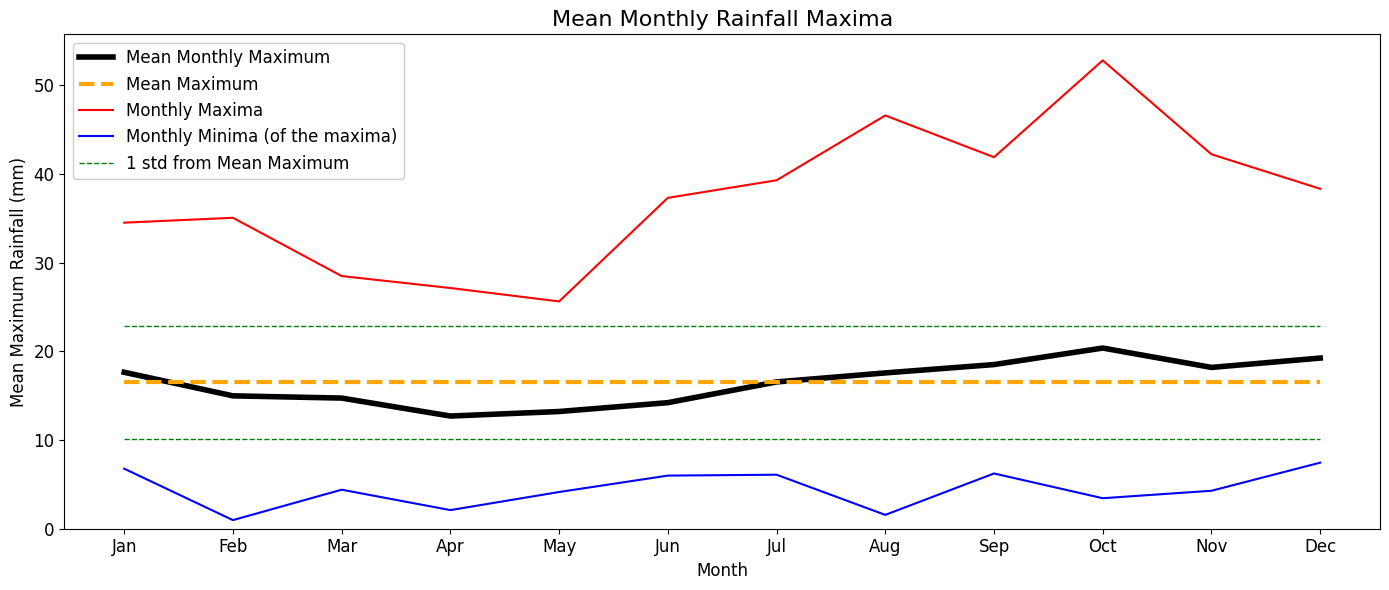

In [7]:
# Find the mean of all months
m_max_mean = m_max_scot['Value'].mean()

# Create the plotting object then plot the values of each month and the mean line
fig, axes = plt.subplots(figsize = (14, 6))

axes.plot(month_names, mean_months_scot['Value'], linewidth = 4, color = 'black', label = 'Mean Monthly Maximum')
axes.hlines(m_max_mean, 0, 11, 'orange', '--', linewidth = 3, label = 'Mean Maximum')

# Plot the maximum and minimum values of the monthly maximums
axes.plot(month_names, max_ovr_monthly_scot['Value'], label = 'Monthly Maxima', color = 'red')
axes.plot(month_names, min_ovr_monthly_scot['Value'], label = 'Monthly Minima (of the maxima)', color = 'blue')

# Plot the lines for 1 standard deviation from the mean
axes.hlines(m_max_mean + std_scot , 0, 11, 'green', '--', linewidth = 1, label = '1 std from Mean Maximum')
axes.hlines(m_max_mean - std_scot , 0, 11, 'green', '--', linewidth = 1)

# Label and clean up the axes
axes.set_xticks(np.arange(0, 12))
axes.set_xticklabels(month_names, fontsize = 12)

axes.set_yticks(np.arange(0, 60, 10))
axes.set_yticklabels(np.arange(0, 60, 10), fontsize = 12)

axes.set_ylim(0, mean_months_scot['Value'].max()*2 + 15)

axes.set_title('Mean Monthly Rainfall Maxima', fontsize = 16)
axes.set_ylabel('Mean Maximum Rainfall (mm)', fontsize = 12)
axes.set_xlabel('Month', fontsize = 12)

plt.tight_layout()

# Add a legend and save the plot
axes.legend(loc = 2, framealpha = 1, fontsize = 12)

# plt.savefig('mean_months_line.pdf')
plt.savefig('imgs/mean_months_line.png')

plt.show()

While this graph does include extra information, it is getting quite messy and unclear. Now that we have so much information to show for each month, a different type of graph would be better. This seems like an ideal use case for something like a box plot, or even better, a violin plot:

## Violin Plot

In [8]:
# Reformat the data for violin plotting
data_for_violin = []
for i in max_months_grp_scot:
    data_for_violin += [list(i[1]['Value'])]

# Find the overall max and min monthly maxima and their corresponding months
max_ovr_month_scot = df_scot[df_scot['Value'] == m_max_scot['Value'].max()]
min_ovr_month_scot = df_scot[df_scot['Value'] == m_max_scot['Value'].min()]

max_ovr_monthly_scot = max_months_grp_scot.max()
min_ovr_monthly_scot = max_months_grp_scot.min()


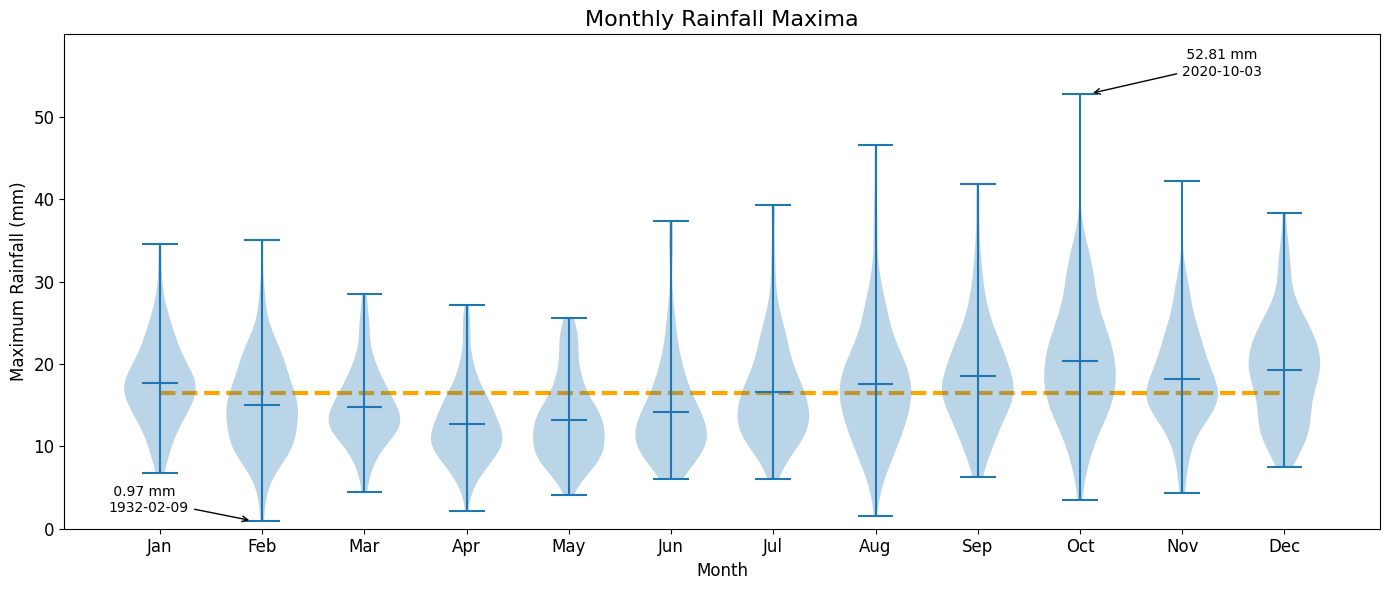

In [9]:
# Create the plotting object then create the violin plot
fig, axes = plt.subplots(figsize = (14, 6))

axes.violinplot(data_for_violin, showmeans = True, showextrema = True, widths = 0.7)

# Plot the horizontal mean line
axes.hlines(m_max_mean, 1, 12, 'orange', '--', linewidth = 3, label = 'Mean Maximum', zorder = -15)

# Annotate the overall max and min points
axes.annotate(' ' + str(max_ovr_month_scot['Value'].iloc[0]) + ' mm\n' + str(max_ovr_month_scot.index[0])[:-9], 
              (9.1+1, m_max_scot['Value'].max()),
              arrowprops = dict(arrowstyle =  '->'), xytext=(10+1, 55), zorder = 100)

axes.annotate(' ' + str(min_ovr_month_scot['Value'].iloc[0]) + ' mm\n' + str(min_ovr_month_scot.index[0])[:-9], 
              (0.9+1, min_ovr_month_scot['Value'].iloc[0]),
              arrowprops = dict(arrowstyle =  '->'), xytext=(-0.5+1, 2), zorder = 100)

# Label and clean up the axes
axes.set_xticks(np.arange(1, 13))
axes.set_xticklabels(month_names, fontsize = 12)

axes.set_yticks(np.arange(0, 60, 10))
axes.set_yticklabels(np.arange(0, 60, 10), fontsize = 12)

axes.set_ylim(0, 60)

axes.set_title('Monthly Rainfall Maxima', fontsize = 16)
axes.set_ylabel('Maximum Rainfall (mm)', fontsize = 12)
axes.set_xlabel('Month', fontsize = 12)

plt.tight_layout()

# Save and present the plot
# plt.savefig('violin.pdf')
plt.savefig('imgs/violin.png')

plt.show()

This graph is much clearer than the last line graph, and is more aesthetically pleasing. We deduct simple information from the graph, such as October having the most extreme rainfall day on record. Additionally, it gives us an idea of the distributions of the data within each month - some months, like June and July, look relatively bottom heavy, while some months, like February, look relatively normally distributed. We can quickly plot a histogram to compare the months.

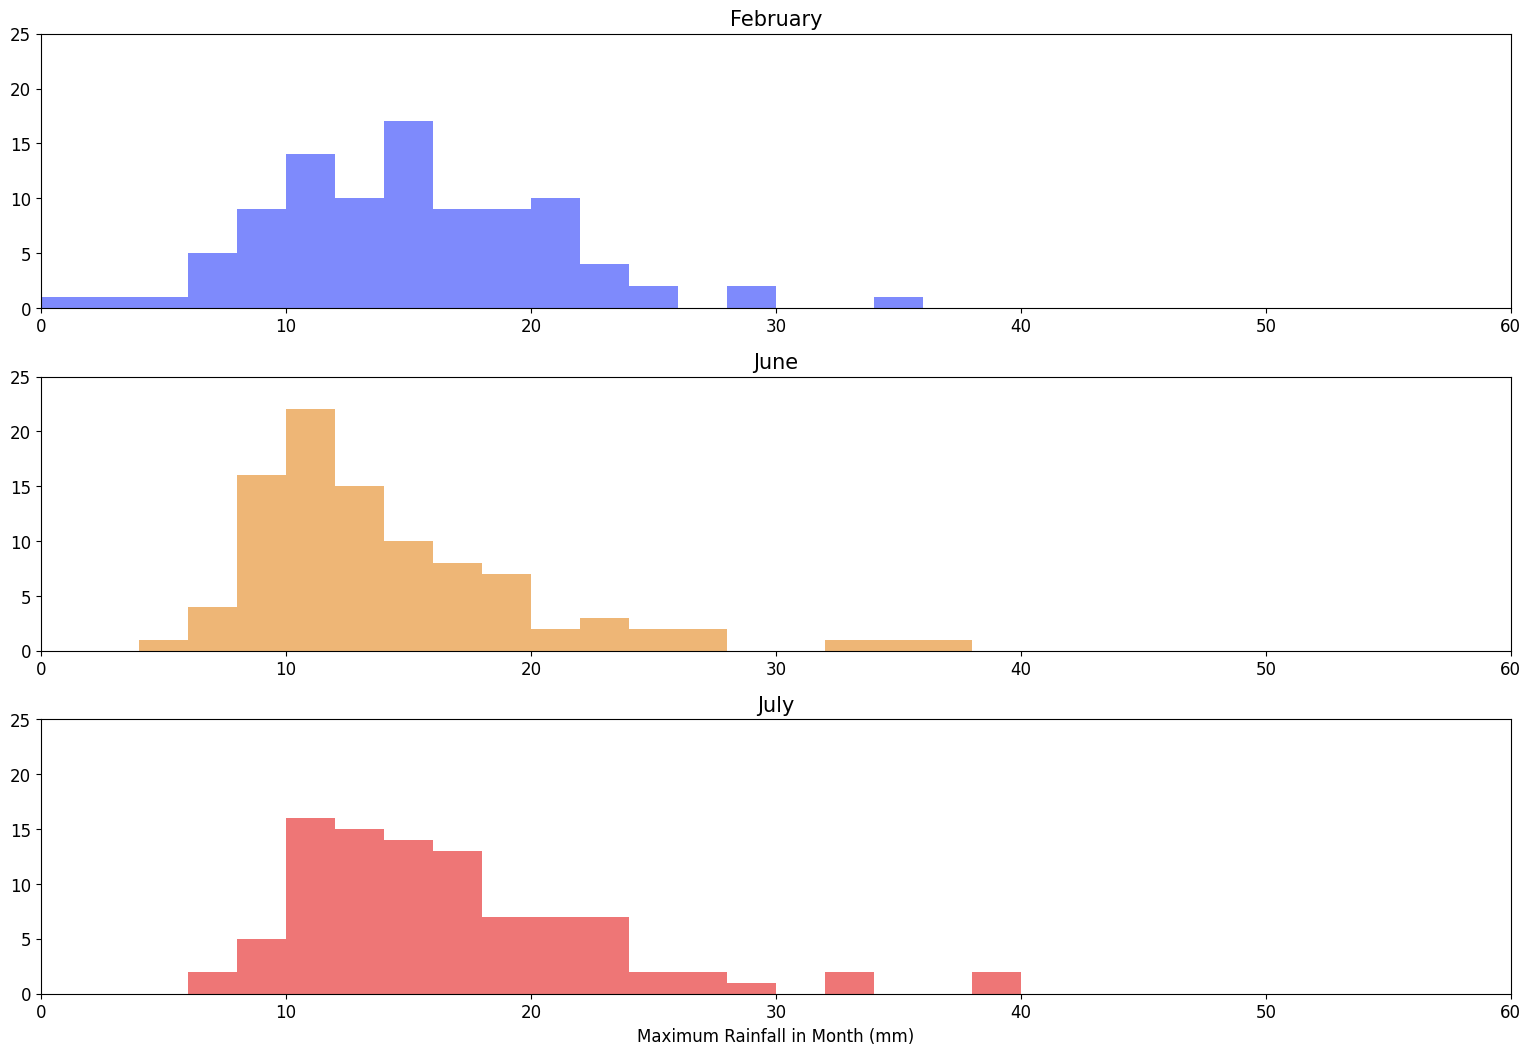

In [10]:
fig, axes = plt.subplots(3, figsize = (15, 12))

axes[0].hist(max_months_grp_scot.get_group(2), bins = 30, label = 'summer', color = "#7E8AFC", range = (0, 60))
axes[0].set_title('February', fontsize = 15)
# axes[0].set_xlabel('Maximum Monthly Rainfall (mm)')

axes[0].set_xlim(0, 60)
axes[0].set_ylim(0, 25)

axes[1].hist(max_months_grp_scot.get_group(6), bins = 30, label = 'winter', color = "#EEB676", range = (0, 60))

axes[1].set_title('June', fontsize = 15)
# axes[1].set_xlabel('Maximum Rainfall in Month (mm)', fontsize = 12)

axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, 25)

axes[2].hist(max_months_grp_scot.get_group(7), bins = 30, label = 'winter', color = "#EE7676", range = (0, 60))

axes[2].set_title('July', fontsize = 15)
axes[2].set_xlabel('Maximum Rainfall in Month (mm)', fontsize = 12)

axes[2].set_xlim(0, 60)
axes[2].set_ylim(0, 25)

for ax in axes:    
    
    ax.set_xticks(np.arange(0, 61, 10))
    ax.set_xticklabels(np.arange(0, 61, 10), fontsize=12)

    ax.set_yticks(np.arange(0, 26, 5))
    ax.set_yticklabels(np.arange(0, 26, 5), fontsize=12)

plt.subplots_adjust(left=0.01, bottom=0.1, right=0.99, top=0.9, wspace=0.1, hspace=0.25)

plt.savefig('imgs/month_hists.png')
plt.show()

Creating a histogram to compare February, June, and July, we can see that while June and July have the higher maximum rainfalls, the majority of their data is further back than February's.